In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
import json
import matplotlib.patches as mpatches

data_dir = Path("/home/bjoern/Projects/Masterarbeit/simdata/server/baseline")

filename_pattern = re.compile(
    r"base(\d+)agent(\d+)_(\d+)-(\d+)#(\d+)"
)

rows = []

for file in data_dir.iterdir():

    if file.suffix != ".json":
        continue

    match = filename_pattern.match(file.stem)

    if not match:
        print(f"Skipping {file.name}")
        continue

    experiment, agent, start, goal, run = map(int, match.groups())

    with open(file) as f:
        data = json.load(f)

    info = data["info"]

    row = {
        "experiment": experiment,
        "agent": agent,
        "start": start,
        "goal": goal,
        "run": run,
        "movement": f"{start}-{goal}",
        "converged": data["trajectory"] is not None,
        "NJS": info.get("NJS"),
        "EE_NJS": info.get("Endeffector_NJS"),
        "Solution_EE_NJS": info.get("Calculated_EE_NJS"),
        "Angle": info.get("Angle"),
        "av_dist_to_target": info.get("av_dist_to_target"),
        "Solution_EE_NJS_cropped" : info.get("EE_NJS_cropped"),
    }

    traj = data["trajectory"]

    if traj is not None:

        points = traj["points"]
        joints = traj["joint_names"]


        joint_pos = {j: [] for j in joints}
       
        for p in points:
            pos = p.get("positions", [])


            # ---- velocities ----
            for j, v in zip(joints, pos):
                joint_pos[j].append(v)

        # store velocities + time
        for j in joints:
            row[f"{j}_pos"] = joint_pos[j]


    rows.append(row)

df = pd.DataFrame(rows)
print(df.head())

   experiment  agent  start  goal  run movement  converged           NJS  \
0          46      2      7     1    2      7-1       True  2.237922e+06   
1          37      2      7     9    1      7-9       True  4.941963e+06   
2          13      1      3     6    2      3-6       True  1.699652e+07   
3          39      2      7     1    2      7-1       True  1.858406e+06   
4          38      2      5     8    2      5-8       True  6.085110e+07   

       EE_NJS  Solution_EE_NJS  ...  \
0  106.194105     7.976347e+05  ...   
1   86.883654     9.339444e+05  ...   
2  161.275011     5.979027e+05  ...   
3  119.390008     6.931827e+05  ...   
4  421.636214     1.649406e+06  ...   

                               columna_rot_joint_pos  \
0  [0.0, -0.0005558228218682684, -0.0003254397231...   
1  [0.0, -0.0005003111946649851, -0.0002391229132...   
2  [0.0, 0.006020835488366511, 0.0077642913510376...   
3  [0.0, -0.000511565629581723, -0.00025843270493...   
4  [0.0, -0.0027398239766932

In [7]:
#limits:
joint_limits = {
    "columna_flex_joint": (0.0, 0.5235987755982988),
    "columna_rot_joint": (-1.2217304763960306, 1.2217304763960306),

    "sternoclavicular_yaw_joint": (-0.08726646259971647, 0.5235987755982988),
    "sternoclavicular_pitch_joint": (-0.5235987755982988, 0.5235987755982988),
    "sternoclavicular_roll_joint": (-0.5235987755982988, 0.5235987755982988),

    "glenohumeral_yaw_joint": (0.0, 1.5707963267948966),
    "glenohumeral_pitch_joint": (-0.6981317007977318, 1.3962634015954636),
    "glenohumeral_roll_joint": (-1.7453292519943295, 1.0471975511965976),

    "elbow_yaw_joint": (-0.2617993877991494, 2.792526803190927),
    "elbow_roll_joint": (-1.5707963267948966, 1.4835298641951802),
}
mirror = {
    1:5,
    2:6,
    3:7,
    4:8,
    5:1,
    6:2, 
    7:3,
    8:4,
    9:9,
}

def mirror_movement(start, goal):
    s = mirror[start]
    g = mirror[goal]
    return f"{s}-{g}"


df["projected_movement"] = np.where(
    df["agent"] == 1,
    df["movement"],
    df.apply(
        lambda r: mirror_movement(r["start"], r["goal"]),
        axis=1
    )
)


✓ No joint limit violations.


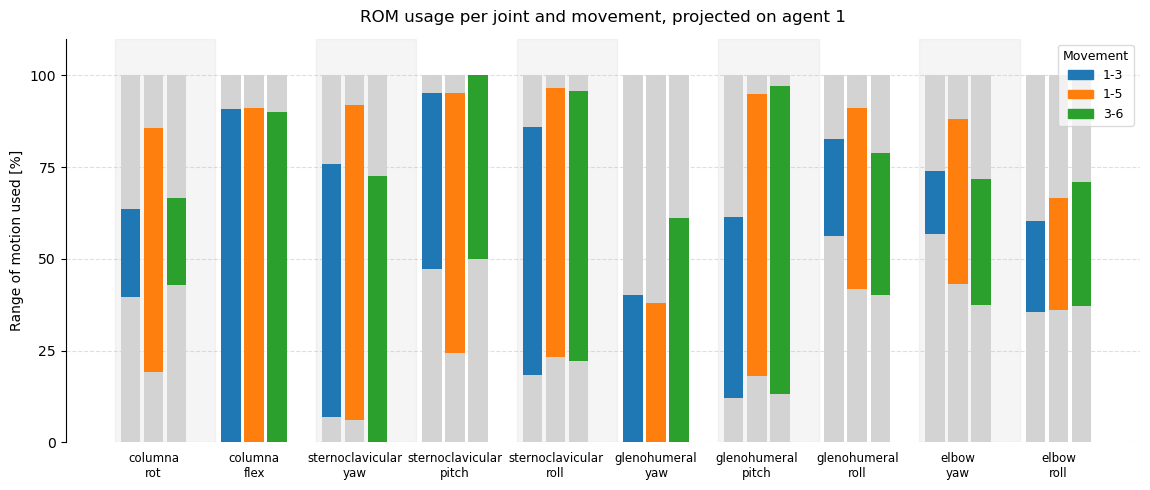

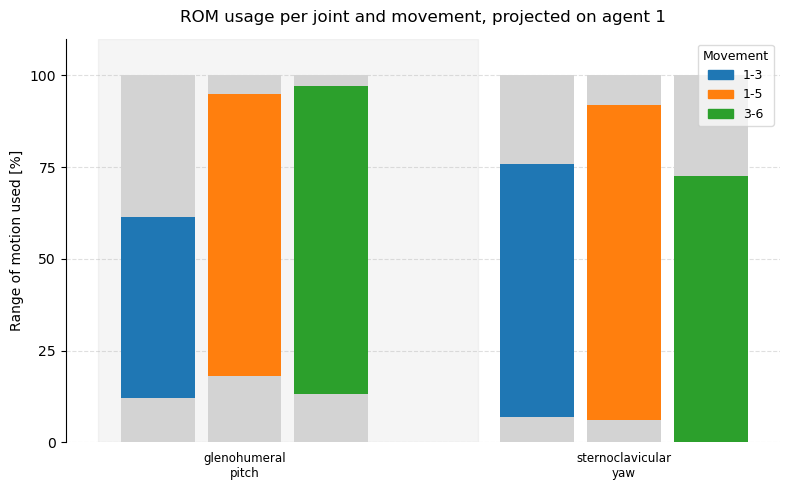

In [ ]:
joint_order = [
"columna_rot_joint",
"columna_flex_joint",
"sternoclavicular_yaw_joint",
"sternoclavicular_pitch_joint",
"sternoclavicular_roll_joint",
"glenohumeral_yaw_joint",
"glenohumeral_pitch_joint",
"glenohumeral_roll_joint",
"elbow_yaw_joint",
"elbow_roll_joint",
]
movements = ["1-3", "1-5", "3-6"]

palette = sns.color_palette()
colors = {mov: palette[i] for i, mov in enumerate(movements)}

# Compute ROM usage + check violations
rom_usage = {}
violations = []

for joint in joint_order:
    col = f"{joint}_pos"
    if col not in df.columns:
        continue
    lo, hi = joint_limits[joint]
    rom_usage[joint] = {}
    for mov in movements:
        subset = df[df["projected_movement"] == mov][col].dropna()
        if subset.empty:
            continue
        all_vals = [v for lst in subset for v in lst]
        mn, mx = min(all_vals), max(all_vals)
        rom_usage[joint][mov] = (mn, mx)
        if mn < lo or mx > hi:
            violations.append({
                "joint": joint, "movement": mov,
                "min": mn, "max": mx,
                "limit_lo": lo, "limit_hi": hi,
                "violation_lo": mn < lo, "violation_hi": mx > hi,
            })

# Report violations
if violations:
    print("⚠️  Joint limit violations detected:")
    for v in violations:
        sides = []
        if v["violation_lo"]:
            sides.append(f"min {v['min']:.4f} < lower limit {v['limit_lo']:.4f}")
        if v["violation_hi"]:
            sides.append(f"max {v['max']:.4f} > upper limit {v['limit_hi']:.4f}")
        print(f"  {v['joint']}  |  movement {v['movement']}  |  {';  '.join(sides)}")
else:
    print("✓ No joint limit violations.")


def plot_rom(joint_subset=None, ax=None):
    """
    Plot ROM usage.
    joint_subset: list of joint names to plot, or None for all.
    ax: existing matplotlib Axes to draw on, or None to create a new figure.
    """
    joints = joint_subset if joint_subset is not None else joint_order
    joints = [j for j in joints if j in rom_usage]

    n_joints = len(joints)
    n_mov = len(movements)
    bar_width = 0.22
    group_gap = 0.3

    standalone = ax is None
    if standalone:
        fig_width = max(8, n_joints * (n_mov * bar_width + group_gap) + 2)
        fig, ax = plt.subplots(figsize=(fig_width, 5))

    xticks, xticklabels = [], []

    for j_idx, joint in enumerate(joints):
        lo, hi = joint_limits[joint]
        rom_range = hi - lo
        base_x = j_idx * (n_mov * bar_width + group_gap)

        # if j_idx % 2 == 0:
        #     ax.axvspan(base_x - group_gap / 2,
        #                base_x + n_mov * bar_width + group_gap / 2,
        #                color="gray", alpha=0.08, zorder=0)

        for m_idx, mov in enumerate(movements):
            x = base_x + m_idx * bar_width
            ax.bar(x, 100, bottom=0, width=bar_width * 0.85,
                   color="lightgray", zorder=1)
            if mov in rom_usage[joint]:
                mn, mx = rom_usage[joint][mov]
                pct_lo = np.clip((mn - lo) / rom_range * 100, 0, 100)
                pct_hi = np.clip((mx - lo) / rom_range * 100, 0, 100)
                ax.bar(x, pct_hi - pct_lo, bottom=pct_lo, width=bar_width * 0.85,
                       color=colors[mov], zorder=2)

        center_x = base_x + (n_mov - 1) * bar_width / 2
        xticks.append(center_x)
        xticklabels.append(joint.replace("_joint", "").replace("_", "\n"))

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, fontsize=8.5)
    ax.set_ylabel("Range of motion used [%]", fontsize=10)
    ax.set_ylim(0, 110)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.tick_params(bottom=False)

    legend_patches = [mpatches.Patch(color=colors[m], label=m) for m in movements]
    ax.legend(handles=legend_patches, title="Movement", fontsize=9,
              title_fontsize=9, loc="upper right", framealpha=0.7)
    ax.set_title("ROM usage per joint and movement, projected on agent 1",
                 fontsize=12, pad=12)

    if standalone:
        plt.tight_layout()
        plt.show()


# Full plot
plot_rom()

# Single-joint example (uncomment when needed):
plot_rom(joint_subset=["sternoclavicular_yaw_joint", "glenohumeral_pitch_joint" ])

In [17]:
rows = []
for joint in joint_order:
    if joint not in rom_usage:
        continue
    lo, hi = joint_limits[joint]
    rom_range = hi - lo
    for mov in movements:
        if mov not in rom_usage[joint]:
            continue
        mn, mx = rom_usage[joint][mov]
        pct_lo = np.clip((mn - lo) / rom_range * 100, 0, 100)
        pct_hi = np.clip((mx - lo) / rom_range * 100, 0, 100)
        rows.append({
            "joint": joint.replace("_joint", "").replace("_", " "),
            "movement": mov,
            "min %": round(pct_lo, 1),
            "max %": round(pct_hi, 1),
        })

table = pd.DataFrame(rows).pivot(index="joint", columns="movement", values=["min %", "max %"])
table = table.reindex([j.replace("_joint", "").replace("_", " ") for j in joint_order])
table.columns = [f"{mov} {stat}" for stat, mov in table.columns]
table = table[[f"{mov} {stat}" for mov in movements for stat in ["min %", "max %"]]]

print(table.to_string())

                        1-3 min %  1-3 max %  1-5 min %  1-5 max %  3-6 min %  3-6 max %
joint                                                                                   
columna rot                  39.6       63.5       19.2       85.6       42.7       66.7
columna flex                  0.0       90.8        0.0       91.2        0.0       90.0
sternoclavicular yaw          7.0       75.9        6.0       91.9        0.0       72.5
sternoclavicular pitch       47.3       95.3       24.5       95.2       50.0      100.0
sternoclavicular roll        18.2       86.0       23.4       96.7       22.3       95.8
glenohumeral yaw              0.0       40.2        0.0       37.8        0.0       61.0
glenohumeral pitch           12.0       61.4       18.1       95.0       13.1       97.1
glenohumeral roll            56.3       82.6       41.7       91.2       40.1       78.8
elbow yaw                    56.6       74.0       43.1       88.1       37.4       71.9
elbow roll           